In [1]:
!pip install tensorflow

In [2]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import Input, Dense, Conv2D, Dropout,BatchNormalization, Flatten,MaxPooling2D
from tensorflow.keras.models import Model
import tensorflow_datasets as tfds

ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/co

In [3]:
(x_train, y_train),(x_test,y_test) = tf.keras.datasets.cifar100.load_data()
#carrega os dados do cifar100


169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 1380s 8us/step


In [4]:
x_train
#ja esta nas dimensoes corretas

array([[[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [195, 205, 193],
         [212, 224, 204],
         [182, 194, 167]],

        [[255, 255, 255],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [170, 176, 150],
         [161, 168, 130],
         [146, 154, 113]],

        [[255, 255, 255],
         [254, 254, 254],
         [255, 255, 255],
         ...,
         [189, 199, 169],
         [166, 178, 130],
         [121, 133,  87]],

        ...,

        [[148, 185,  79],
         [142, 182,  57],
         [140, 179,  60],
         ...,
         [ 30,  17,   1],
         [ 65,  62,  15],
         [ 76,  77,  20]],

        [[122, 157,  66],
         [120, 155,  58],
         [126, 160,  71],
         ...,
         [ 22,  16,   3],
         [ 97, 112,  56],
         [141, 161,  87]],

        [[ 87, 122,  41],
         [ 88, 122,  39],
         [101, 134,  56],
         ...,
         [ 34,  36,  10],
        

In [5]:
y_train = y_train.flatten()
y_test = y_test.flatten()
# tenho que achatar em um vetor pois as classes vem arrays por padrao

In [6]:
K = len(set(y_train))
# descubro a quantidade de classes
K

100

In [9]:
i=Input(x_train[0].shape)# recebe todos os dados de treino, pegando a dimensao dos dados de treino, como a rede espera 3 canais entao os dados estao prontos

x = Conv2D(32, (3,3),activation='relu', padding='same')(i)# faz 32 feature maps para pegar as caracteristicas menores
x=BatchNormalization()(x)
x= Conv2D(32, (3,3),activation='relu', padding='same')(x)# masi uma camada para garantir que todas as caracteristicas sejam obtidas
x=BatchNormalization()(x)
x=MaxPooling2D((2,2))(x)# diminui pela metade o tamanho dos pixels, 16x16

x = Conv2D(64, (3,3),activation='relu', padding='same')(x)
x=BatchNormalization()(x)
x= Conv2D(64, (3,3),activation='relu', padding='same')(x)
x=BatchNormalization()(x)
x=MaxPooling2D((2,2))(x)#8x8

x = Conv2D(128, (3,3),activation='relu', padding='same')(x)
x=BatchNormalization()(x)
x= Conv2D(128, (3,3),activation='relu', padding='same')(x)
x=BatchNormalization()(x)
x=MaxPooling2D((2,2))(x)#4x4

x = Conv2D(256, (3,3),activation='relu', padding='same')(x)
x=BatchNormalization()(x)
x= Conv2D(256, (3,3),activation='relu', padding='same')(x)
x=BatchNormalization()(x)
x=MaxPooling2D((2,2))(x)#2x2

x=Flatten()(x)# oloca tudo em um vetor

x=Dense(1024,activation='relu')(x)# camada densa
x=Dropout(rate=0.3)(x)# desliga alguns neuronios para tentar combater o overfitting
x=Dense(256,activation='relu')(x)
x=Dropout(rate=0.3)(x)

x=Dense(K,activation='softmax')(x)# camada de saida com as K classes

model = Model(i,x)# cria objeto do modelo com as camadas

In [10]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
m=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 404s 256ms/step - accuracy: 0.0406 - loss: 4.3384 - val_accuracy: 0.0641 - val_loss: 4.1264
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 441s 255ms/step - accuracy: 0.0796 - loss: 3.9613 - val_accuracy: 0.1273 - val_loss: 3.6395
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 443s 255ms/step - accuracy: 0.1439 - loss: 3.5650 - val_accuracy: 0.1761 - val_loss: 3.3597
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 400s 256ms/step - accuracy: 0.2097 - loss: 3.1891 - val_accuracy: 0.2808 - val_loss: 2.8120
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 435s 252ms/step - accuracy: 0.2726 - loss: 2.8532 - val_accuracy: 0.3330 - val_loss: 2.5532
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 447s 255ms/step - accuracy: 0.3323 - loss: 2.5733 - val_accuracy: 0.3685 - val_loss: 2.4101
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 398s 255ms/step - accuracy: 0.3818 - loss: 2.3240 - val_accuracy: 0.3959 - val_loss: 2.2783
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 395s 253ms/step - ac

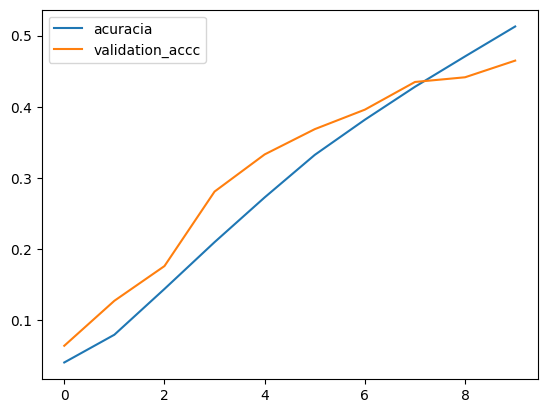

In [11]:
import matplotlib.pyplot as plt
plt.plot(m.history['accuracy'],label='acuracia')
plt.plot(m.history['val_accuracy'],label='validation_accc')
#comparo a acuracia no treino e com dados que nunca viu
plt.legend()

# Podemos analisar que o resultado nao foi o esperado e bem abaixo do esperado quando nos referimos a modelo de CNN. Ao final do treino(ultimas 2 epochs) concluimos que é um possive overfitting, mas anao tao brusco.
# Pelo que vi no kaggle, nao teve muitos notebooks com mais de 70% de acc entao o resultado deste notebook nao foi tao ruim, claro que é somente um teste mas o nivel deste dataset é muito maior que os outros.